In [1]:
import numpy as np


In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('insurance.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

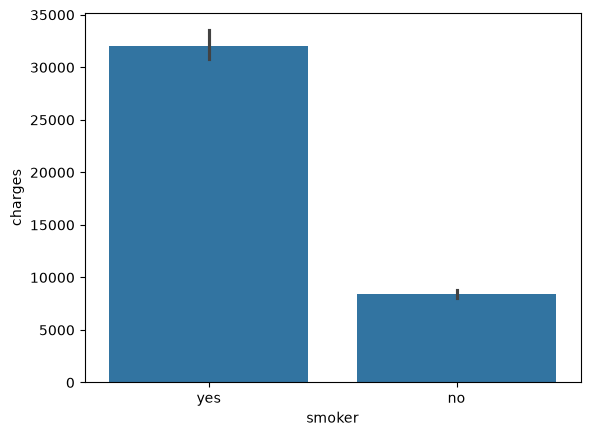

In [9]:
#4. Exploratory Data Analysis (EDA)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=df["smoker"], y=df["charges"])
plt.show()



In [10]:
#5. Feature Engineering

df_encoded = pd.get_dummies(df, drop_first=True)



In [11]:
#6. Feature Selection
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]


In [12]:
#7. Train‑Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [13]:
#8. Feature Scaling (optional for KNN, SVR)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
#9. Model Building
#10. Model Evaluation

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Feature selection
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
pred_lr = lr.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, pred_lr))
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))


R² Score: 0.7835929767120723
MAE: 4181.194473753654
RMSE: 5796.2846592762735


In [15]:
import pickle
pickle.dump(lr, open("model.pkl", "wb"))
